# Model Validation

This notebook validates the selected credit risk model.

Based on the previous model comparison, Histogram Gradient Boosting is selected as the best-performing model.

The purpose of this notebook is to evaluate:

- Probability calibration
- Threshold selection
- Confusion matrix and business interpretation
- Risk decile validation
- Population stability

No default 0.5 threshold is used. The decision threshold is selected based on validation-set performance and business review capacity.

Train: 60%
Validation: 20%
Test: 20%

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix
)

df = pd.read_csv("/content/cs-training.csv")
df = df.rename(columns={"Unnamed: 0": "customer_id"})

target = "SeriousDlqin2yrs"

assert df.shape[0] == 150000, "数据行数不是150000，请检查文件"
assert df[target].isna().sum() == 0, "目标变量存在缺失，请检查数据"

df.loc[df["age"] == 0, "age"] = np.nan

delinquency_columns = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

for column in delinquency_columns:
    df[column] = df[column].replace([96, 98], np.nan)

X = df.drop(columns=["customer_id", target])
y = df[target].astype(int)

X_development, X_test, y_development, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train, X_validation, y_train, y_validation = train_test_split(
    X_development,
    y_development,
    test_size=0.25,
    stratify=y_development,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_validation.shape)
print("Test set:", X_test.shape)

print("Training default rate:", y_train.mean())
print("Validation default rate:", y_validation.mean())
print("Test default rate:", y_test.mean())

Training set: (90000, 10)
Validation set: (30000, 10)
Test set: (30000, 10)
Training default rate: 0.06684444444444444
Validation default rate: 0.06683333333333333
Test default rate: 0.06683333333333333


3. 训练并校准最佳模型

In [2]:
base_model = Pipeline([
    ("preprocessor", SimpleImputer(strategy="median", add_indicator=True)),
    ("classifier", HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42
    ))
])

calibrated_model = CalibratedClassifierCV(
    estimator=base_model,
    method="isotonic",
    cv=3,
    n_jobs=-1
)

calibrated_model.fit(X_train, y_train)

print("Calibrated model training completed.")

Calibrated model training completed.


输出验证集和测试集的概率（这里输出的事客户未来两年严重逾期的预测概率）

In [3]:
validation_probability = calibrated_model.predict_proba(X_validation)[:, 1]
test_probability = calibrated_model.predict_proba(X_test)[:, 1]

print("First 10 validation probabilities:")
print(validation_probability[:10])

print("First 10 test probabilities:")
print(test_probability[:10])

First 10 validation probabilities:
[0.16281176 0.00779914 0.01605032 0.07697927 0.01272193 0.03093306
 0.01605032 0.03514721 0.00782    0.00958648]
First 10 test probabilities:
[0.00647845 0.03625047 0.00684804 0.01047929 0.00996769 0.0018031
 0.0085532  0.64250132 0.01829995 0.0337921 ]


5. 看模型整体表现

In [4]:
def probability_metrics(dataset_name, y_true, y_probability):
    return {
        "dataset": dataset_name,
        "roc_auc": roc_auc_score(y_true, y_probability),
        "average_precision": average_precision_score(y_true, y_probability),
        "brier_score": brier_score_loss(y_true, y_probability),
        "default_rate": y_true.mean()
    }

metrics_table = pd.DataFrame([
    probability_metrics("Validation", y_validation, validation_probability),
    probability_metrics("Test", y_test, test_probability)
])

metrics_table

,dataset,roc_auc,average_precision,brier_score,default_rate
0,Validation,0.864364,0.389380,0.049361,0.066833
1,Test,0.868457,0.405461,0.048731,0.066833


roc_auc：排序能力，越高越好

average_precision：识别少数违约样本的能力，越高越好

brier_score：概率准不准，越低越好

default_rate：真实平均违约率

6. 概率校准曲线

这一步是看模型预测的概率是否靠谱。
比如模型说一组客户平均风险是 20%，那这组人的真实违约率最好也接近 20%。

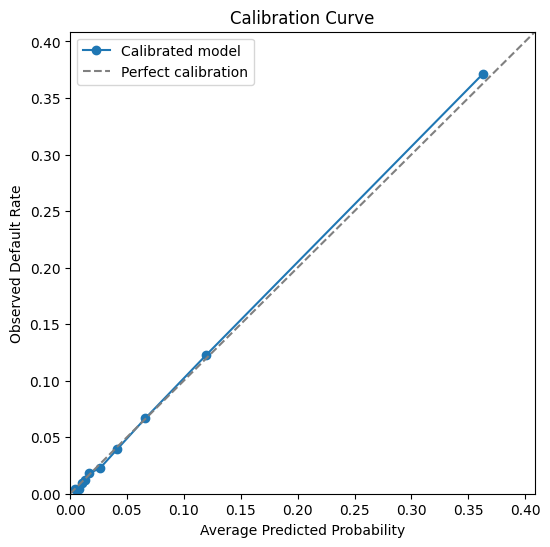

In [5]:
prob_true, prob_pred = calibration_curve(
    y_test,
    test_probability,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(6, 6))

plt.plot(prob_pred, prob_true, marker="o", label="Calibrated model")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")

max_axis = max(prob_pred.max(), prob_true.max()) * 1.1
plt.xlim(0, max_axis)
plt.ylim(0, max_axis)

plt.xlabel("Average Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Curve")
plt.legend()
plt.show()

7. 用验证集选择阈值，不用 0.5（如果风控团队只能重点审核最高风险的 10% 客户，那就把验证集中风险最高 10% 的分界点作为阈值。）

In [6]:
def threshold_performance(y_true, y_probability, threshold):
    y_pred = (y_probability >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    total = tn + fp + fn + tp

    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    review_rate = (tp + fp) / total

    return {
        "threshold": threshold,
        "actual_review_rate": review_rate,
        "precision_default_rate": precision,
        "recall_capture_rate": recall,
        "false_positive_rate": false_positive_rate,
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp
    }

review_rates = [0.05, 0.10, 0.15, 0.20]

threshold_rows = []

for review_rate in review_rates:
    threshold = np.quantile(validation_probability, 1 - review_rate)
    row = threshold_performance(y_validation, validation_probability, threshold)
    row["target_review_rate"] = review_rate
    threshold_rows.append(row)

threshold_table = pd.DataFrame(threshold_rows)

display_threshold_table = threshold_table.copy()

percentage_columns = [
    "target_review_rate",
    "actual_review_rate",
    "precision_default_rate",
    "recall_capture_rate",
    "false_positive_rate"
]

for column in percentage_columns:
    display_threshold_table[column] = display_threshold_table[column] * 100

display_threshold_table

,threshold,actual_review_rate,precision_default_rate,recall_capture_rate,false_positive_rate,true_negatives,false_positives,false_negatives,true_positives,target_review_rate
0,0.325972,5.013333,47.539894,35.660848,2.818360,27206,789,1290,715,5.0
1,0.176457,10.023333,35.916196,53.865337,6.883372,26068,1927,925,1080,10.0
2,0.111419,15.006667,28.609507,64.239401,11.480622,24781,3214,717,1288,15.0
3,0.082493,20.010000,24.021323,71.920200,16.292195,23434,4561,563,1442,20.0


8. 选择最高风险 10% 作为业务阈值

In [7]:
selected_review_rate = 0.10

selected_threshold = threshold_table.loc[
    threshold_table["target_review_rate"] == selected_review_rate,
    "threshold"
].iloc[0]

print("Selected review rate:", selected_review_rate)
print("Selected probability threshold:", selected_threshold)

Selected review rate: 0.1
Selected probability threshold: 0.176456664528879


9. 在测试集上验证这个阈值

In [8]:
test_threshold_performance = threshold_performance(
    y_test,
    test_probability,
    selected_threshold
)

test_threshold_table = pd.DataFrame([test_threshold_performance])

display_test_threshold_table = test_threshold_table.copy()

for column in [
    "actual_review_rate",
    "precision_default_rate",
    "recall_capture_rate",
    "false_positive_rate"
]:
    display_test_threshold_table[column] = display_test_threshold_table[column] * 100

display_test_threshold_table

,threshold,actual_review_rate,precision_default_rate,recall_capture_rate,false_positive_rate,true_negatives,false_positives,false_negatives,true_positives
0,0.176457,10.126667,36.76761,55.710723,6.86194,26074,1921,888,1117


10.混淆矩阵

In [9]:
test_high_risk_prediction = (test_probability >= selected_threshold).astype(int)

confusion = confusion_matrix(y_test, test_high_risk_prediction)

confusion_table = pd.DataFrame(
    confusion,
    index=["Actual non-default", "Actual default"],
    columns=["Predicted low risk", "Predicted high risk"]
)

confusion_table

,Predicted low risk,Predicted high risk
Actual non-default,26074,1921
Actual default,888,1117


11.风险分层验证

In [10]:
test_results = pd.DataFrame({
    "actual_result": y_test.values,
    "predicted_probability": test_probability
})

test_results["risk_decile"] = (
    pd.qcut(
        test_results["predicted_probability"],
        q=10,
        labels=False,
        duplicates="drop"
    ) + 1
)

test_decile_summary = test_results.groupby("risk_decile").agg(
    customer_count=("actual_result", "count"),
    default_count=("actual_result", "sum"),
    observed_default_rate=("actual_result", "mean"),
    average_predicted_probability=("predicted_probability", "mean")
).reset_index()

test_decile_summary["observed_default_rate"] = test_decile_summary["observed_default_rate"] * 100
test_decile_summary["average_predicted_probability"] = test_decile_summary["average_predicted_probability"] * 100

test_decile_summary.sort_values("risk_decile", ascending=False)

,risk_decile,customer_count,default_count,observed_default_rate,average_predicted_probability
9,10,2988,1110,37.148594,36.296181
8,9,2985,365,12.227806,11.927500
7,8,3027,202,6.673274,6.619313
6,7,2983,118,3.955749,4.162568
5,6,2971,68,2.288792,2.659819
4,5,2900,52,1.793103,1.698244
3,4,3135,38,1.212121,1.321116
2,3,2962,28,0.945307,1.016795
1,2,2857,12,0.420021,0.756276
0,1,3192,12,0.375940,0.417811


12.画风险分层图

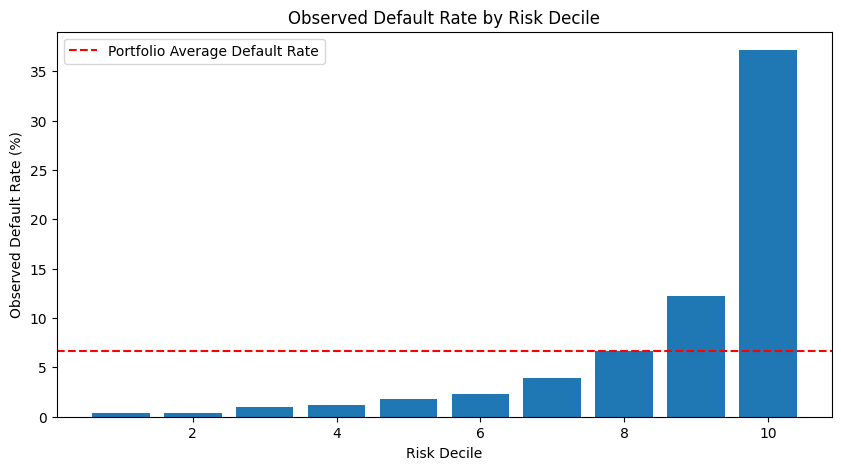

In [12]:
plot_data = test_decile_summary.sort_values("risk_decile")

plt.figure(figsize=(10, 5))

plt.bar(
    plot_data["risk_decile"],
    plot_data["observed_default_rate"]
)

plt.axhline(
    y=y_test.mean() * 100,
    color="red",
    linestyle="--",
    label="Portfolio Average Default Rate"
)

plt.xlabel("Risk Decile")
plt.ylabel("Observed Default Rate (%)")
plt.title("Observed Default Rate by Risk Decile")
plt.legend()
plt.show()

13. 简单 PSI 稳定性检查

PSI 是模型风险管理里常见的稳定性指标。这里我们看训练集和测试集的预测概率分布有没有明显变化。

In [13]:
train_probability = calibrated_model.predict_proba(X_train)[:, 1]

def calculate_psi(expected, actual, buckets=10):
    breakpoints = np.quantile(expected, np.linspace(0, 1, buckets + 1))
    breakpoints = np.unique(breakpoints)

    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf

    expected_counts, _ = np.histogram(expected, bins=breakpoints)
    actual_counts, _ = np.histogram(actual, bins=breakpoints)

    expected_pct = expected_counts / len(expected)
    actual_pct = actual_counts / len(actual)

    expected_pct = np.where(expected_pct == 0, 0.0001, expected_pct)
    actual_pct = np.where(actual_pct == 0, 0.0001, actual_pct)

    psi_values = (actual_pct - expected_pct) * np.log(actual_pct / expected_pct)

    psi_table = pd.DataFrame({
        "bucket": range(1, len(psi_values) + 1),
        "expected_pct": expected_pct,
        "actual_pct": actual_pct,
        "psi": psi_values
    })

    return psi_values.sum(), psi_table

psi_value, psi_table = calculate_psi(train_probability, test_probability)

print("PSI:", psi_value)

psi_table

PSI: 0.0005899157210437226


,bucket,expected_pct,actual_pct,psi
0,1,0.096700,0.096300,1.658033e-06
1,2,0.096833,0.097633,6.582142e-06
2,3,0.105133,0.101467,1.301632e-04
3,4,0.088056,0.084467,1.493371e-04
4,5,0.113256,0.117633,1.660300e-04
5,6,0.099911,0.099267,4.170245e-06
6,7,0.100100,0.103333,1.027887e-04
7,8,0.098656,0.098733,6.129406e-08
8,9,0.101356,0.102467,1.211428e-05
9,10,0.100000,0.098700,1.701081e-05


## Model Validation Summary

This notebook validates the selected Histogram Gradient Boosting credit risk model.

The model is evaluated using calibrated predicted default probabilities.

A default threshold of 0.5 is not used. Instead, the decision threshold is selected based on the validation set and a business review capacity assumption.

In this notebook, the selected strategy is to flag the top 10% highest-risk customers for further review.

The model is then evaluated on the independent test set using:

- ROC-AUC
- Average Precision
- Brier Score
- Confusion matrix
- Precision among flagged high-risk customers
- Recall of actual default customers
- Risk decile analysis
- Population Stability Index

The validation results show whether the model can support credit risk ranking and high-risk customer identification.

Final deployment decisions would still require further business, regulatory, and fairness review.